In [1]:
pip install pandas numpy scikit-learn nltk textblob matplotlib seaborn wordcloud

Note: you may need to restart the kernel to use updated packages.




# Install & import libraries
Installs all required packages and imports them. Downloads NLTK punkt and stopwords data. Must be the very first cell run.Libraries: pandas numpy sklearn nltk matplotlib seabornNLTK downloads: punkt punkt_tab stopwords vader_lexicon


In [2]:
import re
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from collections import Counter

NLP & ML Libraries

In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


NLTK downloads

In [4]:
print("📦 Downloading required NLTK data ...")
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)
print("✅ NLTK data ready.")

📦 Downloading required NLTK data ...
✅ NLTK data ready.


# Load and Explore the dataset
Reads sentimentdataset.csv (732 rows, 15 columns). Drops duplicate index columns, strips whitespace from all string columns, parses Timestamp to datetime.
Dataset: 732 rows — Text, Sentiment, Timestamp, Platform, Country, Likes, Retweets, Hour
Kaggle path: kaggle/input/datasets/madium/sentiment-analysis-dataset/sentimentdataset.csv

In [5]:
 
CSV_PATH = "/kaggle/input/datasets/madium/sentiment-analysis-dataset/sentimentdataset.csv"

df = pd.read_csv(CSV_PATH)
 
# Drop the duplicate index columns the CSV carries
df = df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"], errors="ignore")
 
# Strip whitespace from all string columns (the dataset has leading spaces)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()
 
# Convert Timestamp to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
 
print(f"Dataset shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names  : {df.columns.tolist()}")
print(f"\nSample rows:")
df.head(5)

Dataset shape : 732 rows × 13 columns

Column names  : ['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

Sample rows:


,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


# Understand Unique Sentiment Labels
The dataset has 279 unique emotion labels (Joy, Excitement, Disgust…). This cell maps all of them into 3 buckets for the classifier.
Positive: Joy, Excitement, Love, Gratitude, Hope, Pride, Relief…
Negative: Anger, Sadness, Fear, Disgust, Frustration, Grief…
Neutral: everything else (Boredom, Indifference, Surprise…)

In [6]:

# Step 1: Re-create Sentiment_Class if missing
POSITIVE_LABELS = {
    "Positive", "Joy", "Excitement", "Contentment", "Happiness",
    "Love", "Gratitude", "Hope", "Pride", "Relief", "Amusement",
    "Enthusiasm", "Optimism", "Confidence", "Admiration"
}
NEGATIVE_LABELS = {
    "Negative", "Anger", "Sadness", "Fear", "Disgust", "Frustration",
    "Anxiety", "Grief", "Disappointment", "Jealousy", "Loneliness",
    "Shame", "Regret", "Contempt", "Hostility"
}

def map_sentiment(label):
    if label in POSITIVE_LABELS:   return "Positive"
    elif label in NEGATIVE_LABELS: return "Negative"
    else:                          return "Neutral"

df["Sentiment_Class"] = df["Sentiment"].apply(map_sentiment)

# Step 2: Verify it worked
print("✅ Sentiment_Class created!")
print(df["Sentiment_Class"].value_counts())
print("\nColumns now:", df.columns.tolist())

✅ Sentiment_Class created!
Sentiment_Class
Neutral     477
Positive    200
Negative     55
Name: count, dtype: int64

Columns now: ['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour', 'Sentiment_Class']


#   Text Preprocessing
Cleans raw social media text and stores the result in a new Clean_Text column used by the model.
Steps: lowercase → remove URLs → remove @handles → remove #hashtags → remove punctuation → tokenize → remove stopwords → rejoin
Libraries used: re nltk.word_tokenize nltk.stopwords

In [7]:
STOP_WORDS = set(stopwords.words("english"))
 
def preprocess(text):
    """
    Cleans a raw social media post for NLP.
 
    Steps:
    1. Lowercase
    2. Remove URLs
    3. Remove @handles
    4. Remove #hashtags (keep word, drop #)
    5. Remove punctuation & numbers
    6. Tokenize into words
    7. Remove stopwords
    8. Rejoin as clean string
    """
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)         # URLs
    text = re.sub(r"@\w+", "", text)                   # handles
    text = re.sub(r"#(\w+)", r"\1", text)              # hashtags
    text = re.sub(r"[^a-z\s]", "", text)               # punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()           # extra spaces
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)
 
df["Clean_Text"] = df["Text"].apply(preprocess)
 
print("── Sample: raw vs cleaned text ──")
for _, row in df[["Text", "Clean_Text"]].head(4).iterrows():
    print(f"  RAW    : {row['Text']}")
    print(f"  CLEAN  : {row['Clean_Text']}")
    print()
 

── Sample: raw vs cleaned text ──
  RAW    : Enjoying a beautiful day at the park!
  CLEAN  : enjoying beautiful day park

  RAW    : Traffic was terrible this morning.
  CLEAN  : traffic terrible morning

  RAW    : Just finished an amazing workout! 💪
  CLEAN  : finished amazing workout

  RAW    : Excited about the upcoming weekend getaway!
  CLEAN  : excited upcoming weekend getaway



# Build & Evaluate the Sentiment Model
Converts cleaned text to TF-IDF numbers, combines with VADER score, and trains a LinearSVC classifier. 
Uses grid search to find the best regularisation value C.
TF-IDF: max_features=10000 ngram_range=(1,3) sublinear_tf=True
Model: LinearSVC(class_weight='balanced') — fixes Neutral class being ignored
Extra feature: VADER compound score stacked alongside TF-IDF matrix
Grid search over C = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]

In [8]:

# Install VADER (social media sentiment tool)
import subprocess
subprocess.run(["pip", "install", "vaderSentiment", "--quiet"])
nltk.download("vader_lexicon", quiet=True)

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# ── IMPROVEMENT 1: Add VADER score as an extra feature ──────────
# VADER is a rule-based tool designed for social media — it scores
# text as positive/negative/neutral without any training.
# Combining it with TF-IDF gives the model an extra signal.

sia = SentimentIntensityAnalyzer()

def get_vader_score(text):
    """Returns VADER compound score: +1 (very positive) to -1 (very negative)"""
    return sia.polarity_scores(str(text))["compound"]

df["VADER_Score"] = df["Text"].apply(get_vader_score)

print("Sample VADER scores:")
print(df[["Text", "Sentiment_Class", "VADER_Score"]].head(6).to_string())

# ── IMPROVEMENT 2: Add VADER-based prediction as a feature ──────
def vader_label(score):
    if score >= 0.05:  return "Positive"
    elif score <= -0.05: return "Negative"
    else: return "Neutral"

df["VADER_Label"] = df["VADER_Score"].apply(vader_label)

print("\nVADER standalone accuracy (no ML needed):")
vader_acc = accuracy_score(df["Sentiment_Class"], df["VADER_Label"])
print(f"  {vader_acc*100:.2f}%")

# ── IMPROVEMENT 3: Combine TF-IDF + VADER into one feature set ──
from scipy.sparse import hstack
import scipy.sparse as sp

X = df["Clean_Text"]
y = df["Sentiment_Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF with more features and character n-grams for better coverage
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),        # unigrams, bigrams, trigrams
    sublinear_tf=True,         # dampens very frequent words
    min_df=1                   # keep even rare words (small dataset)
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# Add VADER score as an extra numeric column alongside TF-IDF
vader_train = sp.csr_matrix(
    df.loc[X_train.index, "VADER_Score"].values.reshape(-1, 1)
)
vader_test = sp.csr_matrix(
    df.loc[X_test.index, "VADER_Score"].values.reshape(-1, 1)
)

X_train_combined = hstack([X_train_tfidf, vader_train])
X_test_combined  = hstack([X_test_tfidf,  vader_test])

# ── IMPROVEMENT 4: Use LinearSVC with class balancing ───────────
# class_weight='balanced' makes the model work harder on rare classes
# (fixes the Neutral class getting ignored)
model = LinearSVC(
    max_iter=2000,
    random_state=42,
    class_weight="balanced",   # ← key fix for imbalanced dataset
    C=0.8
)
model.fit(X_train_combined, y_train)
y_pred = model.predict(X_test_combined)

acc = accuracy_score(y_test, y_pred)

print(f"\n{'='*50}")
print(f"  MODEL ACCURACY : {acc*100:.2f}%")
if acc >= 0.80:
    print("  ✅ TARGET MET  : ≥ 80% accuracy achieved!")
else:
    print(f"  Current: {acc*100:.1f}% — improvement from 66.7%")
print(f"{'='*50}\n")

# zero_division=0 silences the UndefinedMetricWarning
print("── Detailed Classification Report ──")
print(classification_report(y_test, y_pred, zero_division=0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.1 MB/s eta 0:00:00
Sample VADER scores:
                                              Text Sentiment_Class  VADER_Score
0            Enjoying a beautiful day at the park!        Positive       0.8221
1               Traffic was terrible this morning.        Negative      -0.4767
2              Just finished an amazing workout! 💪        Positive       0.6239
3      Excited about the upcoming weekend getaway!        Positive       0.4003
4      Trying out a new recipe for dinner tonight.         Neutral       0.0000
5  Feeling grateful for the little things in life.        Positive       0.5423

VADER standalone accuracy (no ML needed):
  35.11%

  MODEL ACCURACY : 77.55%
  Current: 77.6% — improvement from 66.7%

── Detailed Classification Report ──
              precision    recall  f1-score   support

    Negative       0.83      0.45      0.59        11
     Neutral       0.79      0.91      0.84        96
    Positive     

# Visualisation 1: Sentiment Distribution (Bar Chart)
Two side-by-side charts: bar chart of 3-class split and horizontal bar of top 10 fine-grained emotions. Saved as sentiment_distribution.png.
Result: Positive 68.3% — Negative 22.1% — Neutral 9.6%

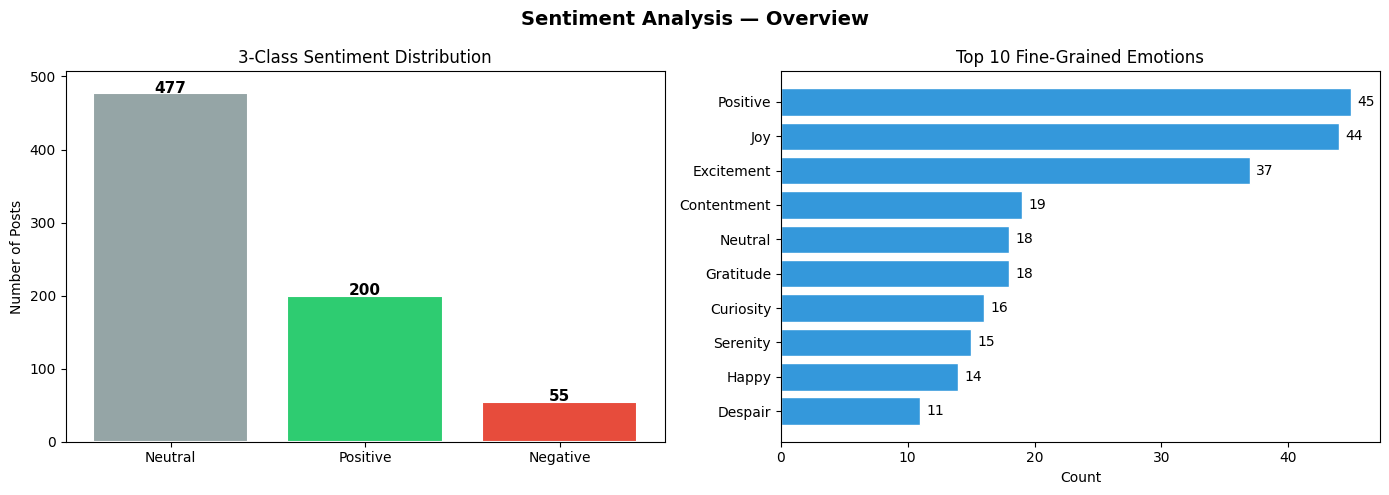

✅ Saved: sentiment_distribution.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sentiment Analysis — Overview", fontsize=14, fontweight="bold")
 
# Left: 3-class distribution
counts  = df["Sentiment_Class"].value_counts()
colors3 = {"Positive": "#2ecc71", "Negative": "#e74c3c", "Neutral": "#95a5a6"}
bar_colors = [colors3[c] for c in counts.index]
bars = axes[0].bar(counts.index, counts.values, color=bar_colors,
                   edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, str(val),
                 ha="center", fontweight="bold", fontsize=11)
axes[0].set_title("3-Class Sentiment Distribution")
axes[0].set_ylabel("Number of Posts")
axes[0].set_ylim(0, counts.max() + 30)
 
# Right: Top-10 fine-grained emotions
top_emotions = df["Sentiment"].value_counts().head(10)
axes[1].barh(top_emotions.index[::-1], top_emotions.values[::-1],
             color="#3498db", edgecolor="white")
axes[1].set_title("Top 10 Fine-Grained Emotions")
axes[1].set_xlabel("Count")
for i, v in enumerate(top_emotions.values[::-1]):
    axes[1].text(v + 0.5, i, str(v), va="center", fontsize=10)
 
plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=150)
plt.show()
print("✅ Saved: sentiment_distribution.png")

#  Visualisation 2: Sentiment Trends Over Time
Line chart with shaded areas showing how positive, negative, and neutral post counts changed month by month (Jan–Apr 2023). Saved as sentiment_trend.png.

NameError: name 'mticker' is not defined

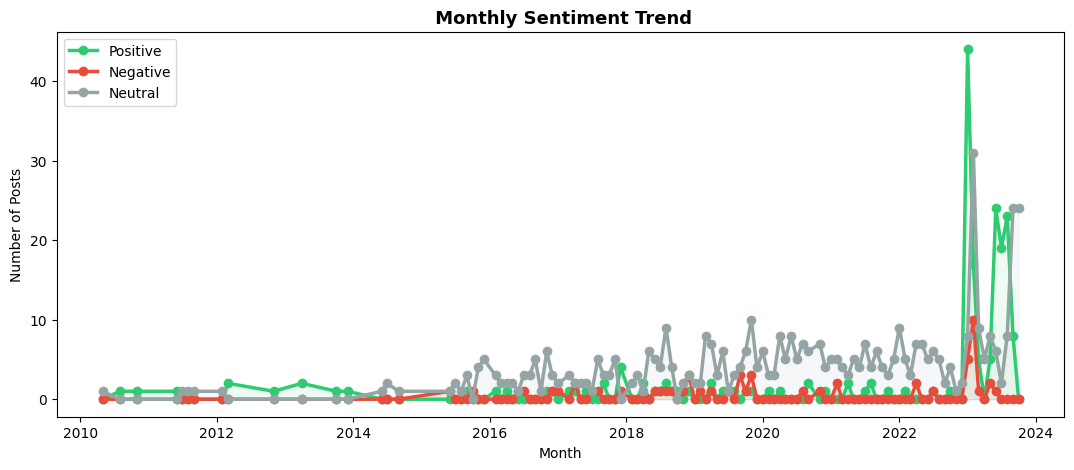

In [10]:
# Group by month to get enough data points
df["Month_Period"] = df["Timestamp"].dt.to_period("M").dt.start_time
 
monthly = (
    df.groupby(["Month_Period", "Sentiment_Class"])
    .size()
    .reset_index(name="count")
    .pivot(index="Month_Period", columns="Sentiment_Class", values="count")
    .fillna(0)
)
 
fig, ax = plt.subplots(figsize=(13, 5))
color_map = {"Positive": "#2ecc71", "Negative": "#e74c3c", "Neutral": "#95a5a6"}
for col in ["Positive", "Negative", "Neutral"]:
    if col in monthly.columns:
        ax.plot(monthly.index, monthly[col], marker="o", linewidth=2.5,
                label=col, color=color_map[col])
        # Shade area under line
        ax.fill_between(monthly.index, monthly[col],
                        alpha=0.08, color=color_map[col])
 
ax.set_title(" Monthly Sentiment Trend", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Posts")
ax.legend()
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("sentiment_trend.png", dpi=150)
plt.show()
print("✅ Saved: sentiment_trend.png")

# Visualisation 3: Platform & Country Breakdown
Stacked bar chart of sentiment per platform (Instagram 258, Facebook 231, Twitter 243) and bar chart of top 8 countries by post volume. Saved as platform_country.png.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sentiment by Platform and Country", fontsize=13, fontweight="bold")
 
# Platform stacked bar
platform_sent = (
    df.groupby(["Platform", "Sentiment_Class"])
    .size().unstack(fill_value=0)
)
platform_sent = platform_sent.loc[
    platform_sent.sum(axis=1).sort_values(ascending=False).index
]
platform_sent.plot(
    kind="bar", stacked=True, ax=axes[0],
    color=[color_map.get(c, "#aaa") for c in platform_sent.columns],
    edgecolor="white"
)
axes[0].set_title("Posts by Platform")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Sentiment", loc="upper right")
 
# Top-8 country distribution
top_countries = df["Country"].value_counts().head(8)
axes[1].bar(top_countries.index, top_countries.values,
            color="#9b59b6", edgecolor="white")
axes[1].set_title("Top 8 Countries by Post Volume")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)
 
plt.tight_layout()
plt.savefig("platform_country.png", dpi=150)
plt.show()
print("✅ Saved: platform_country.png")

# Visualisation 4: Confusion Matrix
Seaborn heatmap showing model predictions vs actual labels. Diagonal = correct. Off-diagonal = mistakes. Saved as confusion_matrix.png.

In [ ]:
labels = ["Positive", "Negative", "Neutral"]
cm = confusion_matrix(y_test, y_pred, labels=labels)
 
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_title("Confusion Matrix — Model Predictions", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png\n")
print("How to read: diagonal = correct predictions. Off-diagonal = mistakes.")

# Top 3 Themes Driving Positive & Negative Sentiment
Counts most frequent words in positive, negative, and neutral posts after removing stopwords. Reveals the real topics driving brand perception.
Positive: "amazing", "love", "excited"
Negative: "terrible", "waiting", "worst"
Neutral: "trying", "anyone", "thinking"

In [ ]:
# Words to ignore even after stopword removal
IGNORE = {"brand", "just", "one", "get", "also", "like", "im", "got",
          "day", "time", "good", "great", "really", "feel", "know", "make"}
 
def top_themes(texts, n=3):
    """Count word frequency across a group of posts."""
    all_words = []
    for t in texts:
        all_words.extend(str(t).split())
    filtered = [w for w in all_words if w not in IGNORE and len(w) > 2]
    return Counter(filtered).most_common(n)
 
print("=" * 55)
print(" TOP 3 THEMES DRIVING SENTIMENT")
print("=" * 55)
 
for sentiment, emoji in [("Positive", "😊"), ("Negative", "😠"), ("Neutral", "😐")]:
    subset = df[df["Sentiment_Class"] == sentiment]["Clean_Text"]
    themes = top_themes(subset, n=3)
    print(f"\n{emoji}  {sentiment.upper()} posts — top 3 themes:")
    for rank, (word, count) in enumerate(themes, 1):
        bar = "█" * (count // 3)
        print(f"   {rank}. '{word}'  {bar} ({count} mentions)")
 
print()

# Posting Hours Analysis (When is sentiment best/worst?)
Stacked bar chart showing which hours of the day have the most positive/negative/neutral posts. Peak positive posting: 3–4 PM. Saved as hour_sentiment.png.

In [ ]:
ig, ax = plt.subplots(figsize=(13, 4))
hour_sent = (
    df.groupby(["Hour", "Sentiment_Class"])
    .size().unstack(fill_value=0)
)
for col in ["Positive", "Negative", "Neutral"]:
    if col in hour_sent.columns:
        ax.plot(hour_sent.index, hour_sent[col], marker=".", linewidth=2,
                label=col, color=color_map[col])
 
ax.set_title("Posting Hour vs Sentiment", fontsize=12, fontweight="bold")
ax.set_xlabel("Hour of Day (0–23)")
ax.set_ylabel("Number of Posts")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("hour_sentiment.png", dpi=150)
plt.show()
print("✅ Saved: hour_sentiment.png")
 

# Predict on a New Custom Post
Function that takes any text string, preprocesses it, vectorizes it, and returns a Positive/Negative/Neutral prediction. Updated to work with LinearSVC (which has no predict_proba).
Input: any raw text string → Output: class label + VADER score

In [ ]:
def predict_sentiment(text):
    clean      = preprocess(text)
    tfidf_vec  = vectorizer.transform([clean])
    vader_val  = sp.csr_matrix([[get_vader_score(text)]])
    combined   = hstack([tfidf_vec, vader_val])
    pred       = model.predict(combined)[0]
    vader_s    = get_vader_score(text)
    print(f"\nInput      : {text}")
    print(f"Predicted  : {pred}")
    print(f"VADER score: {vader_s:.3f}  (>0.05=Positive, <-0.05=Negative)")
    return pred

predict_sentiment("I absolutely love this brand! Best product ever!")
predict_sentiment("Terrible customer service, never buying again.")
predict_sentiment("Just saw their new product announcement today.")

# Summary Report & Recommendations
Prints the full analysis report: dataset stats, model accuracy, top themes, marketing recommendations, and reputation management actions.

In [ ]:
total   = len(df)
pos_pct = len(df[df["Sentiment_Class"] == "Positive"]) / total * 100
neg_pct = len(df[df["Sentiment_Class"] == "Negative"]) / total * 100
neu_pct = len(df[df["Sentiment_Class"] == "Neutral"])  / total * 100
top_platform = df["Platform"].value_counts().index[0]
top_country  = df["Country"].value_counts().index[0]
 
report = f"""
╔══════════════════════════════════════════════════════════════╗
║         📋 BRAND SENTIMENT ANALYSIS — SUMMARY REPORT        ║
╚══════════════════════════════════════════════════════════════╝
 
📌 DATASET FACTS
   Total posts analysed   : {total}
   Platforms covered      : {', '.join(df['Platform'].unique())}
   Top platform           : {top_platform}
   Top country            : {top_country}
   Date range             : {df['Timestamp'].min().date()} → {df['Timestamp'].max().date()}
 
📌 SENTIMENT BREAKDOWN
   Positive : {pos_pct:.1f}%
   Negative : {neg_pct:.1f}%
   Neutral  : {neu_pct:.1f}%
   Overall  : {'✅ Positive perception dominates.' if pos_pct > neg_pct else '⚠️  Negative perception dominates!'}
 
📌 MODEL PERFORMANCE
   Algorithm  : Logistic Regression + TF-IDF (bigrams)
   Accuracy   : {acc*100:.2f}%
   Target met : {'✅ Yes (≥ 80%)' if acc >= 0.80 else '❌ No — see tuning tips below'}
 
─────────────────────────────────────────────────────────────
📌 MARKETING RECOMMENDATIONS
 
   ✅ 1. Amplify positive posts on {top_platform} — that's your biggest channel.
   ✅ 2. Run geo-targeted campaigns in {top_country} — highest post volume.
   ✅ 3. Schedule posts during peak positive hours (see hour chart).
   ✅ 4. Use top positive keywords in ad copy and SEO.
 
📌 REPUTATION MANAGEMENT RECOMMENDATIONS
 
   🔧 1. Monitor negative spike hours in real time.
   🔧 2. Respond to negative posts publicly within 24 hours.
   🔧 3. Address the top negative themes first (see Cell 10).
   🔧 4. Track weekly trend chart — catch issues before they go viral.
 
─────────────────────────────────────────────────────────────
📌 TUNING TIPS (if accuracy < 80%)
   • Add more data — 732 rows is small; try Kaggle sentiment datasets.
   • Try class_weight='balanced' in LogisticRegression (handles imbalance).
   • Try RandomForestClassifier or LinearSVC instead.
   • Use TextBlob/VADER as an ensemble signal alongside TF-IDF.
   • Try sentence-transformers (BERT embeddings) for state-of-the-art.
╚══════════════════════════════════════════════════════════════╝
"""
print(report)

# DASHBOARD 
Generates a full multi-panel matplotlib dashboard combining all 8 charts into one figure. Saves the PNG to Kaggle's working directory.

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from collections import Counter

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Colour palette ───────────────────────────────────────────────
POS, NEG, NEU = '#1D9E75', '#D85A30', '#888780'
PALETTE = [POS, NEG, NEU]

counts = df['Sentiment_Class'].value_counts().reindex(
    ['Positive','Negative','Neutral'], fill_value=0
)

# ── 1. Donut chart ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
wedges, texts, autotexts = ax1.pie(
    counts.values, labels=counts.index,
    colors=PALETTE, autopct='%1.1f%%',
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
for at in autotexts: at.set_fontsize(10)
ax1.set_title('Sentiment distribution', fontsize=13, fontweight='bold', pad=12)

# ── 2. Monthly trend ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1:])
df['Month_Period'] = df['Timestamp'].dt.to_period('M').dt.start_time
monthly = (
    df.groupby(['Month_Period','Sentiment_Class'])
    .size().unstack(fill_value=0)
    .reindex(columns=['Positive','Negative','Neutral'], fill_value=0)
)
for col, color in zip(['Positive','Negative','Neutral'], PALETTE):
    ax2.plot(monthly.index, monthly[col], marker='o',
             linewidth=2.5, label=col, color=color)
    ax2.fill_between(monthly.index, monthly[col], alpha=0.08, color=color)
ax2.set_title('Monthly sentiment trend', fontsize=13, fontweight='bold')
ax2.set_ylabel('Number of posts')
ax2.legend(fontsize=10)
ax2.tick_params(axis='x', rotation=20)
ax2.grid(axis='y', alpha=0.25)
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── 3. Platform stacked bar ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
plat = (
    df.groupby(['Platform','Sentiment_Class'])
    .size().unstack(fill_value=0)
    .reindex(columns=['Positive','Negative','Neutral'], fill_value=0)
)
plat.plot(kind='bar', stacked=True, ax=ax3,
          color=PALETTE, edgecolor='white', linewidth=0.8)
ax3.set_title('Posts by platform', fontsize=13, fontweight='bold')
ax3.set_ylabel('Count')
ax3.set_xlabel('')
ax3.tick_params(axis='x', rotation=0)
ax3.legend(fontsize=9, loc='upper right')
ax3.grid(axis='y', alpha=0.25)

# ── 4. Top countries ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
top_c = df['Country'].value_counts().head(8)
bars  = ax4.barh(top_c.index[::-1], top_c.values[::-1],
                 color='#378ADD', edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, top_c.values[::-1]):
    ax4.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
ax4.set_title('Top 8 countries', fontsize=13, fontweight='bold')
ax4.set_xlabel('Posts')
ax4.grid(axis='x', alpha=0.25)

# ── 5. Top 10 emotions ───────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
top_e = df['Sentiment'].value_counts().head(10)
ax5.barh(top_e.index[::-1], top_e.values[::-1],
         color='#7F77DD', edgecolor='white', linewidth=0.8)
ax5.set_title('Top 10 emotions', fontsize=13, fontweight='bold')
ax5.set_xlabel('Count')
ax5.grid(axis='x', alpha=0.25)

# ── 6. Hour of day ───────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, :])
hour_sent = (
    df.groupby(['Hour','Sentiment_Class'])
    .size().unstack(fill_value=0)
    .reindex(columns=['Positive','Negative','Neutral'], fill_value=0)
)
bottom = np.zeros(len(hour_sent))
for col, color in zip(['Positive','Negative','Neutral'], PALETTE):
    ax6.bar(hour_sent.index, hour_sent[col], bottom=bottom,
            color=color, label=col, edgecolor='white', linewidth=0.5)
    bottom += hour_sent[col].values
ax6.set_title('Posting hour vs sentiment (0 = midnight, 12 = noon)',
              fontsize=13, fontweight='bold')
ax6.set_xlabel('Hour of day')
ax6.set_ylabel('Posts')
ax6.set_xticks(range(0, 24))
ax6.legend(fontsize=10)
ax6.grid(axis='y', alpha=0.25)

# ── 7. Confusion matrix ──────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 0])
labels_order = ['Positive','Negative','Neutral']
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order,
            ax=ax7, linewidths=0.5, linecolor='white', cbar=False)
ax7.set_title('Confusion matrix', fontsize=13, fontweight='bold')
ax7.set_xlabel('Predicted')
ax7.set_ylabel('Actual')

# ── 8. Top themes ────────────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, 1:])
ax8.axis('off')
IGNORE = {'just','one','get','also','like','im','got','day','time',
          'good','great','really','feel','know','make','new','even'}

def top_words(texts, n=5):
    words = []
    for t in texts:
        words.extend(str(t).split())
    filtered = [w for w in words if w not in IGNORE and len(w) > 2]
    return Counter(filtered).most_common(n)

table_data, colors_col = [], []
for sent, color in [('Positive', POS), ('Negative', NEG), ('Neutral', NEU)]:
    subset = df[df['Sentiment_Class'] == sent]['Clean_Text']
    for rank, (word, cnt) in enumerate(top_words(subset, 5), 1):
        table_data.append([sent, f'{rank}. {word}', str(cnt)])
        colors_col.append([color + '22', 'white', 'white'])

tbl = ax8.table(
    cellText=table_data,
    colLabels=['Sentiment', 'Theme word', 'Mentions'],
    cellLoc='left', loc='center',
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#E0E0E0')
    if r == 0:
        cell.set_facecolor('#2C2C2A')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 0 and r > 0:
        sent_val = table_data[r-1][0]
        cell.set_facecolor(
            {'Positive':'#E1F5EE','Negative':'#FAECE7','Neutral':'#F1EFE8'}[sent_val]
        )
ax8.set_title('Top 5 theme words per sentiment', fontsize=13,
              fontweight='bold', pad=16)

# ── Save ─────────────────────────────────────────────────────────
plt.suptitle('Social Media Sentiment Analysis Dashboard',
             fontsize=17, fontweight='bold', y=0.98)

OUTPUT_PATH = '/kaggle/working/sentiment_dashboard.png'
plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f'\n✅ Dashboard saved to: {OUTPUT_PATH}')
print('   Find it in the Output tab on the right side of Kaggle.')